# H6 — Engagement Across Countries

## 1. Business Question

**How does user engagement evolve over time across countries?**

### Hypothesis

User engagement varies across countries over time.

### Analytical objective

Determine whether engagement differs across countries at user level, while distinguishing:

- descriptive country differences,
- the role of calendar time versus user maturity,
- statistical evidence,
- practical relevance,
- and the limits of causal interpretation.

This analysis does not claim that country itself causes engagement.


## 2. Analytical Setup

### Unit of analysis

**One row per user.**

The analysis compares user-level engagement status against user country. The time dimension is examined only after the grain and the meaning of `activity_period` have been established.

### Definitions

**Engaged user**

A user who completes at least one successful transaction in **3 of the previous 4 weeks** before the evaluation point used by the approved engagement model.

**Activity period**

In `mart_engagement`, `activity_period` corresponds to the week associated with the user’s last successful transaction activity in the analytical window. It is not a repeated longitudinal observation per user.

### Analytical variables

| Variable | Meaning |
|---|---|
| `user_id` | Unique user identifier |
| `engagement_flag` | User-level engagement classification |
| `activity_period` | Week associated with the user’s last successful activity |
| `country` | User country |
| `plan_segment` | Plan segment (STANDARD / PREMIUM) |
| `created_at` | User creation date (used to construct tenure) |

The Mart supplies the validated user-level context. Tenure is derived from `created_at` and `activity_period` rather than rebuilt from raw transaction events inside the notebook.


## 3. Data & Analytical Population

The analysis uses the final validated `mart_engagement` table in BigQuery, joined to `stg_users` for activation date.

Before comparison, the notebook verifies:

- expected columns are present,
- the dataset is one row per user,
- required analytical fields contain valid values,
- and the mature analytical population is established before country comparison.


In [1]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

client = bigquery.Client(project="le-wagon-da-502302")

query = '''
SELECT
    m.user_id,
    m.engagement_flag,
    m.activity_period,
    m.country,
    m.plan_segment,
    u.created_at
FROM `le-wagon-da-502302.NeoBank.mart_engagement` m
LEFT JOIN `le-wagon-da-502302.NeoBank.stg_users` u
    ON m.user_id = u.user_id
WHERE m.activity_period IS NOT NULL
'''

df = client.query(query).to_dataframe()

expected_columns = {
    "user_id",
    "engagement_flag",
    "activity_period",
    "country",
    "plan_segment",
    "created_at",
}

missing_columns = expected_columns - set(df.columns)
if missing_columns:
    raise ValueError(f"Missing expected columns: {sorted(missing_columns)}")

if len(df) != df["user_id"].nunique():
    raise ValueError("mart_engagement is not one row per user.")

df["activity_period"] = pd.to_datetime(df["activity_period"]).dt.date
df["created_at"] = pd.to_datetime(df["created_at"]).dt.date
df["tenure_weeks"] = (
    (pd.to_datetime(df["activity_period"]) - pd.to_datetime(df["created_at"])).dt.days / 7
).round(1)
df["engagement_flag"] = df["engagement_flag"].astype(bool)

print("Mart shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nMissing values:")
print(df.isna().sum())
print("\nUnique users:", df["user_id"].nunique())
print("\nEngagement rate (all users):", df["engagement_flag"].mean())


Mart shape: (18529, 7)

Columns:
['user_id', 'engagement_flag', 'activity_period', 'country', 'plan_segment', 'created_at', 'tenure_weeks']

Missing values:
user_id            0
engagement_flag    0
activity_period    0
country            0
plan_segment       0
created_at         0
tenure_weeks       0
dtype: int64

Unique users: 18529

Engagement rate (all users): 0.31448000431755624


In [2]:
# Mature analytical population: users with at least 12 weeks of history.
# The engagement definition is not evaluable for very short tenures.

mature = df[df["tenure_weeks"] >= 12].copy()

country_n = mature.groupby("country")["user_id"].nunique()
core_countries = country_n[country_n >= 40].index.tolist()
mature_core = mature[mature["country"].isin(core_countries)].copy()

print("Mature users (≥12 weeks):", len(mature))
print("Core countries (≥40 mature users):", len(core_countries))
print("\nEngagement rate (mature core):", mature_core["engagement_flag"].mean())
print("\nCountry counts (top 10):")
print(country_n.sort_values(ascending=False).head(10))


Mature users (≥12 weeks): 15414
Core countries (≥40 mature users): 29

Engagement rate (mature core): 0.37816445345718586

Country counts (top 10):
country
GB    4889
PL    1895
FR    1654
IE    1081
RO     945
ES     765
LT     525
MT     507
PT     456
CH     357
Name: user_id, dtype: int64


## 4. Structure of Time and Engagement Eligibility

Before interpreting any calendar-time pattern, the notebook establishes what `activity_period` represents and when engagement can theoretically become true.


In [3]:
period_summary = (
    df.groupby("activity_period")
      .agg(
          users=("user_id", "nunique"),
          engaged=("engagement_flag", "sum"),
          rate=("engagement_flag", "mean"),
      )
      .reset_index()
      .sort_values("activity_period")
)
period_summary["rate_pct"] = period_summary["rate"] * 100

print("First period with any engaged users:")
first_true = period_summary.loc[period_summary["engaged"] > 0, "activity_period"].min()
print(first_true)

print("\nLate window (2019-04-15 onwards):")
print(
    period_summary[period_summary["activity_period"] >= pd.to_datetime("2019-04-15").date()]
    .to_string(index=False, formatters={"rate": "{:.4f}".format, "rate_pct": "{:.1f}%".format})
)


First period with any engaged users:
2019-04-29

Late window (2019-04-15 onwards):
activity_period  users  engaged   rate rate_pct
     2019-04-15    760        0 0.0000     0.0%
     2019-04-22   1229        0 0.0000     0.0%
     2019-04-29   2490      930 0.3735    37.3%
     2019-05-06   6222     4837 0.7774    77.7%
     2019-05-13     70       60 0.8571    85.7%


In [4]:
# Tenure gradient: engagement becomes possible only after sufficient history.
hist_bins = [-1, 4, 8, 12, 16, 26, 52, 999]
hist_labels = ["0-4w", "5-8w", "9-12w", "13-16w", "17-26w", "27-52w", "52w+"]
df["history_band"] = pd.cut(df["tenure_weeks"], bins=hist_bins, labels=hist_labels)

tenure_summary = (
    df.groupby("history_band", observed=True)
      .agg(
          users=("user_id", "nunique"),
          engaged=("engagement_flag", "sum"),
          rate=("engagement_flag", "mean"),
      )
      .reset_index()
)
tenure_summary["rate_pct"] = tenure_summary["rate"] * 100
tenure_summary


,history_band,users,engaged,rate,rate_pct
0,0-4w,1969,0,0.0000,0.0000
1,5-8w,613,0,0.0000,0.0000
2,9-12w,550,0,0.0000,0.0000
3,13-16w,710,0,0.0000,0.0000
4,17-26w,3733,1246,0.3338,33.3780
5,27-52w,7731,3073,0.3975,39.7491
6,52w+,3223,1508,0.4679,46.7887


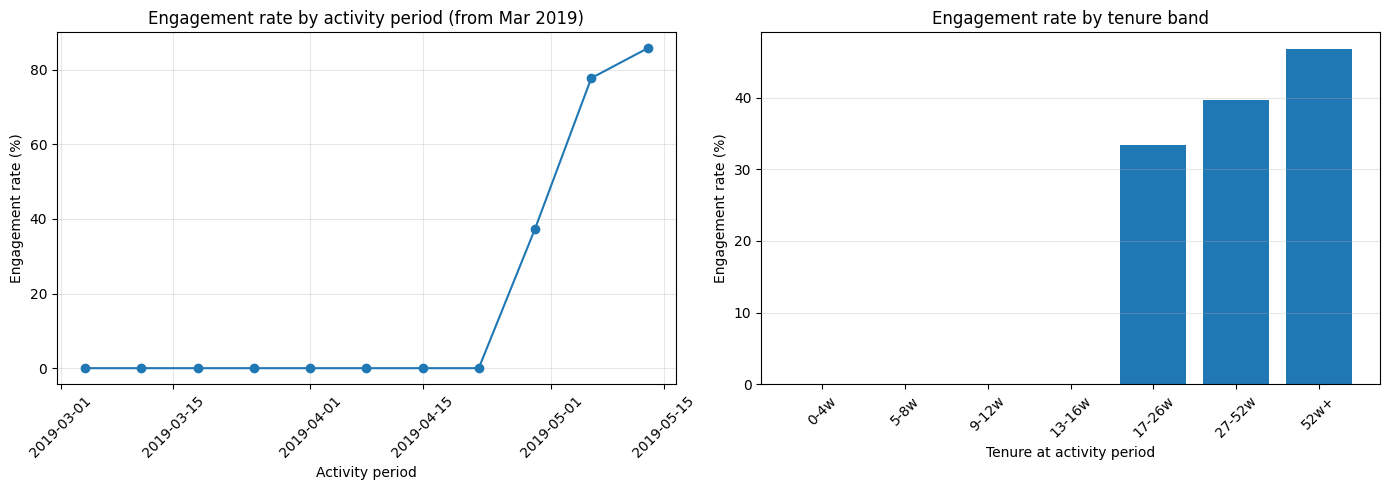

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: engagement by activity period (late window only for readability)
late = period_summary[period_summary["activity_period"] >= pd.to_datetime("2019-03-01").date()]
axes[0].plot(late["activity_period"], late["rate_pct"], marker="o")
axes[0].set_title("Engagement rate by activity period (from Mar 2019)")
axes[0].set_ylabel("Engagement rate (%)")
axes[0].set_xlabel("Activity period")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(True, alpha=0.3)

# Right: engagement by tenure band
axes[1].bar(tenure_summary["history_band"].astype(str), tenure_summary["rate_pct"])
axes[1].set_title("Engagement rate by tenure band")
axes[1].set_ylabel("Engagement rate (%)")
axes[1].set_xlabel("Tenure at activity period")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


The calendar series shows a long structural zero period followed by a sharp rise in the final weeks of the dataset. The tenure view shows that engagement is effectively zero for short histories and only becomes material after roughly 17 weeks. Combined with the one-row-per-user grain, this indicates that the apparent time trend is largely driven by eligibility and by the concentration of last-activity weeks near the end of the observation window, rather than by a genuine product-wide change in engagement behaviour.


## 5. Country Differences (Mature Users)

The primary comparison restricts to mature users (≥12 weeks tenure) and to countries with at least 40 mature users. This reduces the influence of short-tenure structural zeros and of very small markets.


In [6]:
country_rank = (
    mature_core.groupby("country")
               .agg(
                   users=("user_id", "nunique"),
                   engaged=("engagement_flag", "sum"),
                   rate=("engagement_flag", "mean"),
                   median_tenure=("tenure_weeks", "median"),
               )
               .reset_index()
               .sort_values("rate", ascending=False)
)
country_rank["rate_pct"] = country_rank["rate"] * 100

print("Highest engagement countries:")
print(country_rank.head(10).to_string(
    index=False,
    formatters={"rate": "{:.4f}".format, "rate_pct": "{:.1f}%".format}
))

print("\nLowest engagement countries:")
print(country_rank.tail(8).sort_values("rate").to_string(
    index=False,
    formatters={"rate": "{:.4f}".format, "rate_pct": "{:.1f}%".format}
))

top = country_rank.iloc[0]
bottom = country_rank.iloc[-1]
print(f"\nAbsolute gap (top – bottom): {top['rate_pct'] - bottom['rate_pct']:.1f} pp")
print(f"Relative lift (top / bottom): {top['rate'] / bottom['rate']:.2f}x")


Highest engagement countries:
country  users  engaged   rate  median_tenure rate_pct
     MT    507      306 0.6036        30.3000    60.4%
     IE   1081      623 0.5763        32.9000    57.6%
     GI     41       23 0.5610        42.6000    56.1%
     RO    945      513 0.5429        30.4000    54.3%
     CY    144       70 0.4861        31.5500    48.6%
     LV    129       61 0.4729        36.9000    47.3%
     LT    525      225 0.4286        44.4000    42.9%
     CZ    293      123 0.4198        34.1000    42.0%
     CH    357      149 0.4174        34.9000    41.7%
     SI     73       27 0.3699        32.9000    37.0%

Lowest engagement countries:
country  users  engaged   rate  median_tenure rate_pct
     AT     65       15 0.2308        33.4000    23.1%
     GR    128       31 0.2422        34.0000    24.2%
     DK     80       20 0.2500        34.8000    25.0%
     HU    117       32 0.2735        36.4000    27.4%
     PT    456      137 0.3004        32.3500    30.0%
     

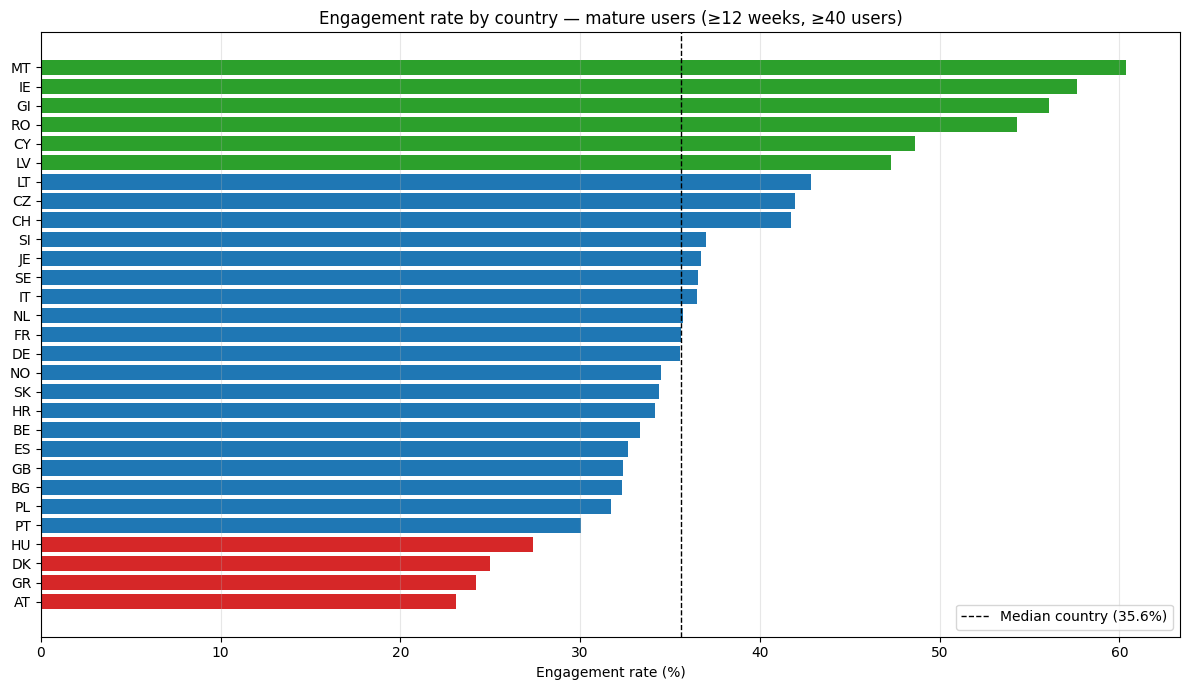

In [7]:
fig, ax = plt.subplots(figsize=(12, 7))

plot_df = country_rank.sort_values("rate")
colours = ["#2ca02c" if r >= 0.45 else "#d62728" if r <= 0.30 else "#1f77b4"
           for r in plot_df["rate"]]

ax.barh(plot_df["country"], plot_df["rate_pct"], color=colours)
ax.axvline(country_rank["rate_pct"].median(), color="black", linestyle="--", linewidth=1,
           label=f"Median country ({country_rank['rate_pct'].median():.1f}%)")
ax.set_xlabel("Engagement rate (%)")
ax.set_title("Engagement rate by country — mature users (≥12 weeks, ≥40 users)")
ax.legend(loc="lower right")
ax.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.show()


In [8]:
# Kruskal-Wallis test across core countries
groups = [
    g["engagement_flag"].astype(int).values
    for _, g in mature_core.groupby("country")
]
h_stat, p_value = stats.kruskal(*groups)

print(f"Kruskal-Wallis H = {h_stat:.3f}")
print(f"p-value = {p_value:.4g}")
print(f"Countries included = {len(groups)}")


Kruskal-Wallis H = 573.534
p-value = 4.29e-103
Countries included = 29


Country differences among mature users are large. The top markets sit near 55–60% engagement; the lowest sit near 23–25%. The absolute gap exceeds 35 percentage points. The Kruskal–Wallis test strongly rejects the hypothesis that all countries share the same engagement distribution.


## 6. Robustness Checks

The country ranking is re-examined under several alternative cuts:

- within plan segment,
- inside a narrow tenure band,
- after removing the largest markets by volume.


In [9]:
print("=== Within STANDARD plan ===")
std = mature_core[mature_core["plan_segment"] == "STANDARD"]
std_rank = (
    std.groupby("country")
       .agg(users=("user_id", "nunique"), rate=("engagement_flag", "mean"))
       .reset_index()
       .query("users >= 20")
       .sort_values("rate", ascending=False)
)
std_rank["rate_pct"] = std_rank["rate"] * 100
print(std_rank.head(8).to_string(
    index=False,
    formatters={"rate": "{:.4f}".format, "rate_pct": "{:.1f}%".format}
))

print("\n=== Narrow tenure band (27–52 weeks) ===")
narrow = mature_core[
    (mature_core["tenure_weeks"] >= 27) &
    (mature_core["tenure_weeks"] <= 52)
]
narrow_rank = (
    narrow.groupby("country")
          .agg(users=("user_id", "nunique"), rate=("engagement_flag", "mean"))
          .reset_index()
          .query("users >= 30")
          .sort_values("rate", ascending=False)
)
narrow_rank["rate_pct"] = narrow_rank["rate"] * 100
print(narrow_rank.head(8).to_string(
    index=False,
    formatters={"rate": "{:.4f}".format, "rate_pct": "{:.1f}%".format}
))

print("\n=== After excluding GB, PL, FR ===")
reduced = mature_core[~mature_core["country"].isin(["GB", "PL", "FR"])]
reduced_groups = [
    g["engagement_flag"].astype(int).values
    for _, g in reduced.groupby("country")
    if len(g) >= 30
]
h_red, p_red = stats.kruskal(*reduced_groups)
print(f"Kruskal-Wallis H = {h_red:.3f}, p = {p_red:.4g}")
print(f"Countries remaining = {len(reduced_groups)}")


=== Within STANDARD plan ===
country  users   rate rate_pct
     MT    491 0.5967    59.7%
     GI     38 0.5789    57.9%
     IE   1040 0.5760    57.6%
     RO    869 0.5305    53.0%
     CY    135 0.4741    47.4%
     LV    119 0.4454    44.5%
     LT    515 0.4272    42.7%
     CH    334 0.4042    40.4%

=== Narrow tenure band (27–52 weeks) ===
country  users   rate rate_pct
     MT    242 0.6860    68.6%
     IE    531 0.6064    60.6%
     RO    467 0.6017    60.2%
     CY     66 0.4697    47.0%
     CH    177 0.4463    44.6%
     LV     65 0.4462    44.6%
     CZ    148 0.4392    43.9%
     IT    102 0.4216    42.2%

=== After excluding GB, PL, FR ===
Kruskal-Wallis H = 352.448, p = 1.547e-59
Countries remaining = 26


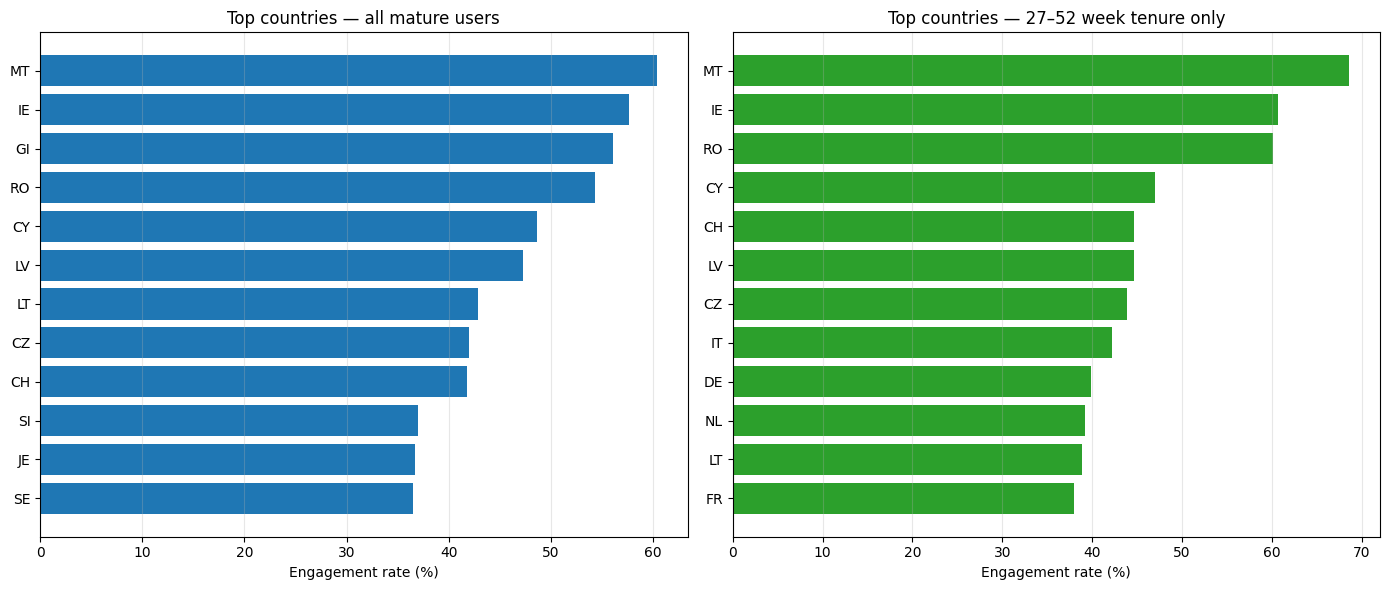

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Overall mature ranking (top 12)
top12 = country_rank.head(12).sort_values("rate")
axes[0].barh(top12["country"], top12["rate_pct"], color="#1f77b4")
axes[0].set_title("Top countries — all mature users")
axes[0].set_xlabel("Engagement rate (%)")
axes[0].grid(True, axis="x", alpha=0.3)

# Narrow tenure ranking (top 12)
top12_n = narrow_rank.head(12).sort_values("rate")
axes[1].barh(top12_n["country"], top12_n["rate_pct"], color="#2ca02c")
axes[1].set_title("Top countries — 27–52 week tenure only")
axes[1].set_xlabel("Engagement rate (%)")
axes[1].grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.show()


The ranking is stable. Malta, Ireland and Romania remain near the top under STANDARD plan users and inside the 27–52 week tenure band. After excluding the three largest markets, the Kruskal–Wallis test remains highly significant and the same high-engagement countries continue to lead. Tenure mix and large-market volume are not driving the result.


## 7. Interpretation

The evidence is interpreted at four levels.

### Descriptive association

Mature users show large cross-country differences in engagement. The highest markets sit near 55–60%; the lowest sit near 23–25%.

### Role of calendar time

The apparent rise in engagement over calendar time is largely structural. It reflects:

1. the engagement definition only becoming evaluable after sufficient user history, and  
2. the concentration of users’ last-activity weeks in the final weeks of the dataset.

It should not be read as a genuine product-wide increase in engagement behaviour over calendar time.

### Statistical evidence

The Kruskal–Wallis test on mature core countries strongly rejects equality of engagement distributions across countries. The result remains significant after removal of the largest markets.

### Practical relevance

The absolute gap between the highest and lowest core countries exceeds 35 percentage points. On a per-100-user basis this is a material difference.

### Causality

The analysis is observational. Country differences may reflect product availability, local payment behaviour, acquisition mix, plan penetration, or other unmeasured factors. The evidence supports treating country as a meaningful engagement segment, not as a proven causal driver.


## 8. Final Finding

### H6 — Partially supported / qualified association

**Country differences in engagement are real, large, and robust.**  
After restricting to mature users and applying multiple sensitivity checks, clear and statistically supported differences remain across countries.

**The apparent evolution of engagement over calendar time is not supported as a genuine behavioural trend.**  
It is largely explained by the engagement eligibility window and by the structure of `activity_period` in the analytical mart.

### Business-story handoff

The evidence that should move into the **Notion knowledge / business layer** is:

- the robust ranking of countries by mature-user engagement,
- the magnitude of the gap between high- and low-engagement markets,
- the structural explanation for the calendar-time pattern,
- the distinction between association and causation,
- and the implication that country is a useful segmentation dimension for engagement, while calendar-time trends from the current mart should be interpreted with caution.

The final business recommendation belongs in Notion and the presentation layer, not in this evidence notebook.
